## ðŸ‘©â€ðŸ’» Author

[![GitHub](https://img.shields.io/badge/GitHub-Profile-blue?style=for-the-badge&logo=github)](https://github.com/zohaakhawajaa)
[![Kaggle](https://img.shields.io/badge/Kaggle-Profile-blue?style=for-the-badge&logo=kaggle)](https://www.kaggle.com/zohakhawaja)
[![LinkedIn](https://img.shields.io/badge/LinkedIn-Profile-blue?style=for-the-badge&logo=linkedin)](https://www.linkedin.com/in/zoha-khawaja-99671831b/)
[![X](https://img.shields.io/badge/X-Profile-black?style=for-the-badge&logo=x)](https://x.com/zohaakhawajaa)

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

RANDOM_STATE = 42

## 1. Load the data



In [ ]:
df_train = pd.read_csv("../dataset/train.csv")
df_test = pd.read_csv("../dataset/test.csv")


df = df_train.copy()

print("Training shape:", df_train.shape)
print("Test shape:", df_test.shape)

Training shape: (165034, 14)
Test shape: (110023, 13)


### Dataset and Initial Inspection

the selected dataset is a real-world customer churn dataset and the dataset is inspected before model development.

##  Basic data inspection

##  Duplicate Record Check and Cleaning

duplicate records should be checked and removed where present. The following additional cell checks the original training dataframe and removes exact duplicate rows before the existing feature/target preparation is reached.

In [4]:
# check and remove exact duplicate rows.
duplicate_count = df.duplicated().sum()
print("Duplicate rows found:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicate rows removed:", duplicate_count)
else:
    print("No duplicate rows found. Dataset remains unchanged.")

print("Dataset shape after duplicate check:", df.shape)


Duplicate rows found: 0
No duplicate rows found. Dataset remains unchanged.
Dataset shape after duplicate check: (165034, 14)


In [5]:
display(df.head())
print("\nData information:")
df.info()

print("\nDescriptive statistics:")
display(df.describe().T)

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0



Data information:
<class 'pandas.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               165034 non-null  int64  
 1   CustomerId       165034 non-null  int64  
 2   Surname          165034 non-null  str    
 3   CreditScore      165034 non-null  int64  
 4   Geography        165034 non-null  str    
 5   Gender           165034 non-null  str    
 6   Age              165034 non-null  float64
 7   Tenure           165034 non-null  int64  
 8   Balance          165034 non-null  float64
 9   NumOfProducts    165034 non-null  int64  
 10  HasCrCard        165034 non-null  float64
 11  IsActiveMember   165034 non-null  float64
 12  EstimatedSalary  165034 non-null  float64
 13  Exited           165034 non-null  int64  
dtypes: float64(5), int64(6), str(3)
memory usage: 17.6 MB

Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
id,165034.0,8.251650e+04,47641.356500,0.00,41258.25,82516.5,1.237748e+05,165033.00
CustomerId,165034.0,1.569201e+07,71397.816791,15565701.00,15633141.00,15690169.0,1.575682e+07,15815690.00
CreditScore,165034.0,6.564544e+02,80.103340,350.00,597.00,659.0,7.100000e+02,850.00
Age,165034.0,3.812589e+01,8.867205,18.00,32.00,37.0,4.200000e+01,92.00
Tenure,165034.0,5.020353e+00,2.806159,0.00,3.00,5.0,7.000000e+00,10.00
Balance,165034.0,5.547809e+04,62817.663278,0.00,0.00,0.0,1.199395e+05,250898.09
NumOfProducts,165034.0,1.554455e+00,0.547154,1.00,1.00,2.0,2.000000e+00,4.00
HasCrCard,165034.0,7.539537e-01,0.430707,0.00,1.00,1.0,1.000000e+00,1.00
IsActiveMember,165034.0,4.977702e-01,0.499997,0.00,0.00,0.0,1.000000e+00,1.00
EstimatedSalary,165034.0,1.125748e+05,50292.865585,11.58,74637.57,117948.0,1.551525e+05,199992.48


###  Missing Values Requirement

The existing analysis checks the percentage of missing values in each column.

If the analysis shows no missing values, no imputation is required. If missing values are present, the appropriate handling strategy should be documented.

## Missing-value analysis

,Missing %
id,0.0
CustomerId,0.0
Surname,0.0
CreditScore,0.0
Geography,0.0
Gender,0.0
Age,0.0
Tenure,0.0
Balance,0.0
NumOfProducts,0.0


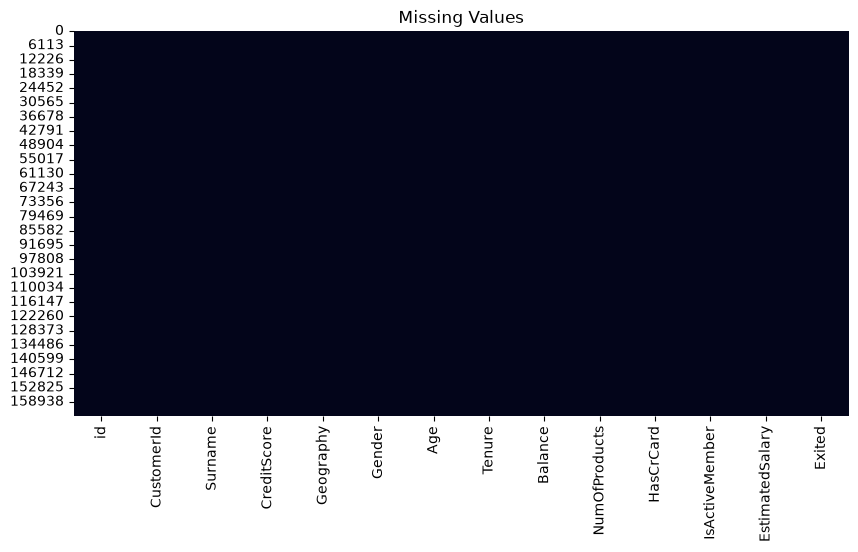

In [6]:
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
display(missing.to_frame("Missing %"))

plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

### Classification Target

`Exited` is the binary classification target. The target distribution is examined before training so that the class proportions are understood.

##  Target distribution

Exited
0    130113
1     34921
Name: count, dtype: int64

Target proportions:
Exited
0    0.788401
1    0.211599
Name: proportion, dtype: float64


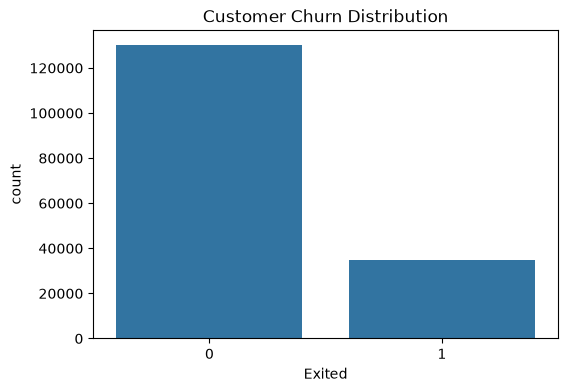

In [7]:
print(df["Exited"].value_counts())
print("\nTarget proportions:")
print(df["Exited"].value_counts(normalize=True))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Exited")
plt.title("Customer Churn Distribution")
plt.show()

##  Categorical feature analysis

In [8]:
cat_cols = [
    "Geography", "Gender", "Tenure", "NumOfProducts",
    "HasCrCard", "IsActiveMember", "Exited"
]

for col in cat_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


Geography
Geography
France     94215
Spain      36213
Germany    34606
Name: count, dtype: int64

Gender
Gender
Male      93150
Female    71884
Name: count, dtype: int64

Tenure
Tenure
2     18045
7     17810
4     17554
8     17520
5     17268
1     16760
9     16709
3     16630
6     15822
10     5909
0      5007
Name: count, dtype: int64

NumOfProducts
NumOfProducts
2    84291
1    77374
3     2894
4      475
Name: count, dtype: int64

HasCrCard
HasCrCard
1.0    124428
0.0     40606
Name: count, dtype: int64

IsActiveMember
IsActiveMember
0.0    82885
1.0    82149
Name: count, dtype: int64

Exited
Exited
0    130113
1     34921
Name: count, dtype: int64


##  Numerical feature analysis

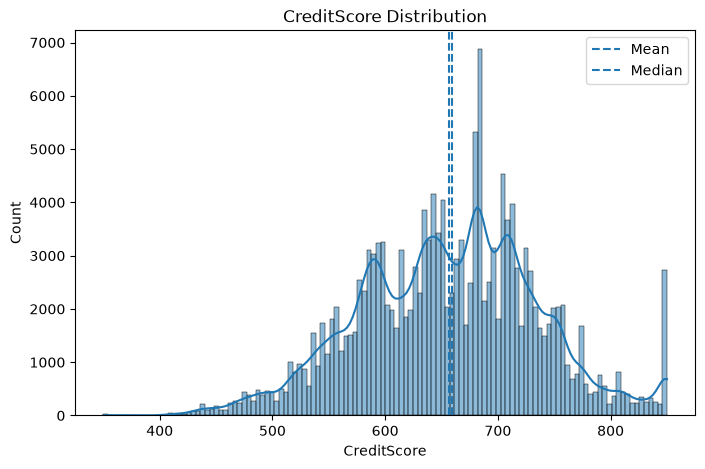

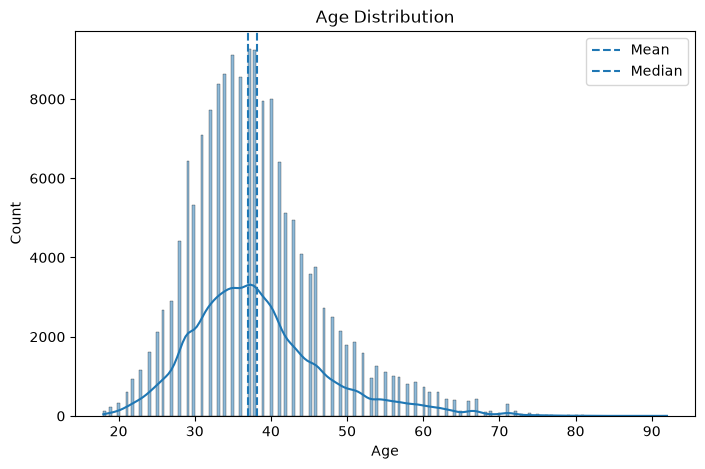

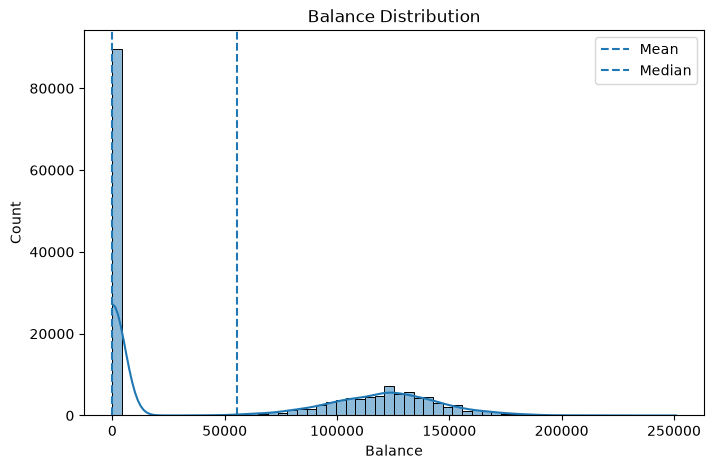

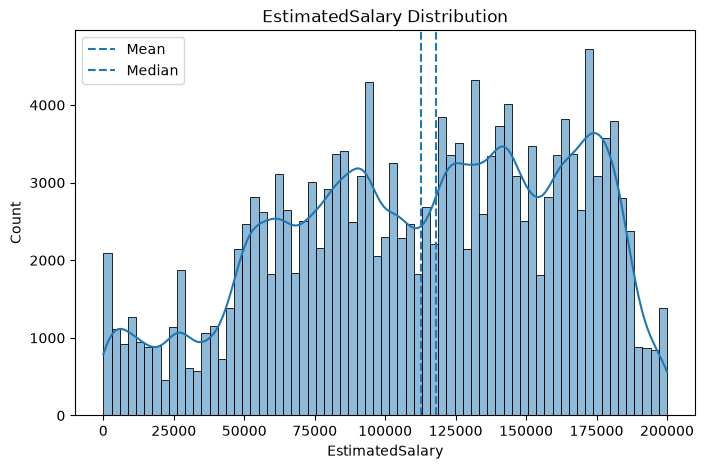

In [9]:
num_cols = ["CreditScore", "Age", "Balance", "EstimatedSalary"]

for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], kde=True)
    plt.axvline(df[col].mean(), linestyle="--", label="Mean")
    plt.axvline(df[col].median(), linestyle="--", label="Median")
    plt.title(f"{col} Distribution")
    plt.legend()
    plt.show()

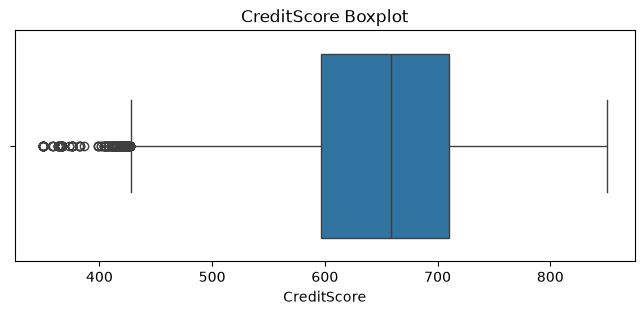

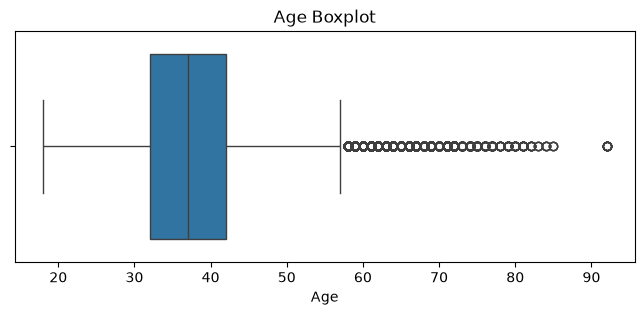

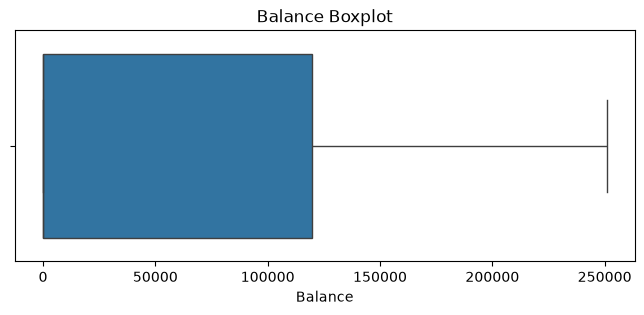

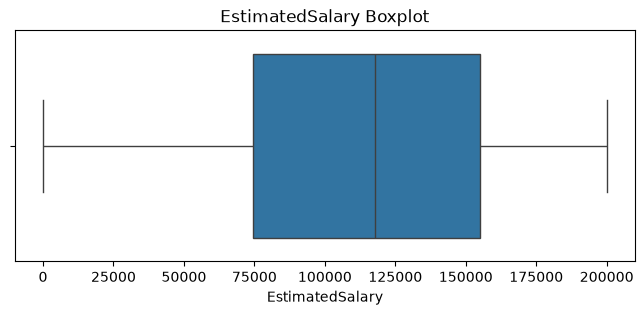

In [10]:
for col in num_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col])
    plt.title(f"{col} Boxplot")
    plt.show()

##  Correlation analysis

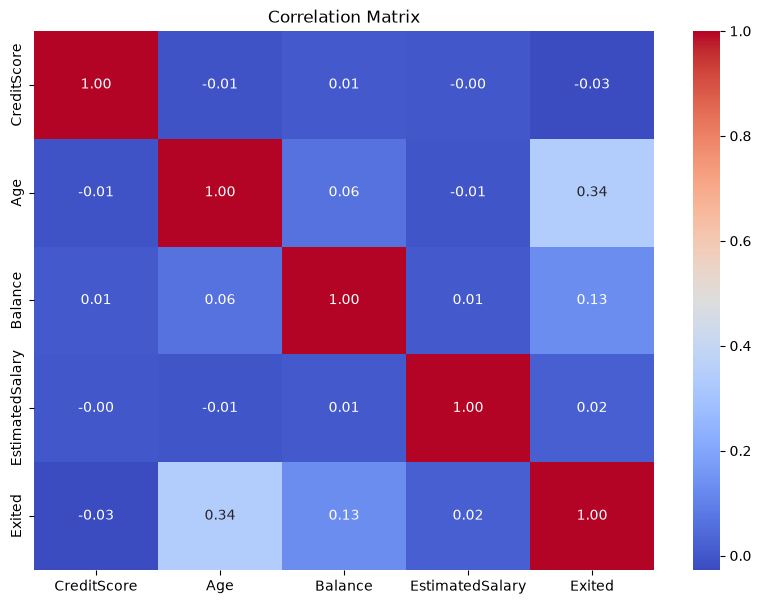

In [11]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    df[num_cols + ["Exited"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

### Feature/Target Separation

The identifier columns are excluded because they are identifiers rather than predictive customer attributes. `X` contains the model inputs and `y` contains the churn target.

## Define features and target

Identifier columns are excluded from the model.

- `X` = input features
- `y` = target

In [12]:
X = df.drop(["Exited", "id", "CustomerId", "Surname"], axis=1)
y = df["Exited"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (165034, 10)
y shape: (165034,)


### Train/Validation/Test Split

The existing project uses three subsets:

- **Training set:** used to fit the models.
- **Validation set:** used for model comparison and tuning decisions.
- **Held-out test set:** reserved for final evaluation after model selection.

This separation helps prevent the final test performance from influencing model selection.

## Train / validation / test split

In [13]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Training: (115523, 10)
Validation: (24755, 10)
Test: (24756, 10)


### Encoding and Scaling

- Categorical features are encoded with **One-Hot Encoding**.
- Numerical features are transformed using **StandardScaler**.
- The transformations are contained in a `ColumnTransformer` and used through model pipelines.

Keeping preprocessing inside the pipeline helps ensure that transformations are learned from the training data rather than from the validation/test data.

## Preprocessing

Categorical features use `OneHotEncoder`; numerical features use `StandardScaler`.

The transformations are placed inside a `ColumnTransformer` and fitted through each model pipeline, which helps prevent preprocessing leakage.

In [14]:
categorical_features = ["Geography", "Gender"]

numerical_features = [
    "CreditScore", "Age", "Tenure", "Balance",
    "NumOfProducts", "HasCrCard", "IsActiveMember",
    "EstimatedSalary"
]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

### Evaluation Metrics

Because this is a binary classification problem, the required classification metrics are used:

- **Accuracy**
- **Precision**
- **Recall**
- **F1 Score**
- **Confusion Matrix**

ROC-AUC is also included as an additional metric.

## Evaluation helper

In [15]:
def evaluate_model(model, X_val, y_val, model_name):
    pred = model.predict(X_val)
    prob = model.predict_proba(X_val)[:, 1]

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_val, pred),
        "Precision": precision_score(y_val, pred, zero_division=0),
        "Recall": recall_score(y_val, pred, zero_division=0),
        "F1": f1_score(y_val, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_val, prob)
    }

## Logistic Regression â€” baseline

In [16]:
lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_val)
lr_prob = lr_model.predict_proba(X_val)[:, 1]

print(classification_report(y_val, lr_pred))
print("ROC-AUC:", roc_auc_score(y_val, lr_prob))

              precision    recall  f1-score   support

           0       0.85      0.96      0.90     19517
           1       0.70      0.38      0.50      5238

    accuracy                           0.84     24755
   macro avg       0.78      0.67      0.70     24755
weighted avg       0.82      0.84      0.82     24755

ROC-AUC: 0.8186279892703952


## Decision Tree

In [17]:
dt_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE))
])

dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_val)

print(classification_report(y_val, dt_pred))

              precision    recall  f1-score   support

           0       0.89      0.95      0.92     19517
           1       0.73      0.55      0.63      5238

    accuracy                           0.86     24755
   macro avg       0.81      0.75      0.77     24755
weighted avg       0.85      0.86      0.85     24755



## 14. Random Forest

In [18]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_val)

print(classification_report(y_val, rf_pred))

              precision    recall  f1-score   support

           0       0.88      0.95      0.91     19517
           1       0.72      0.53      0.61      5238

    accuracy                           0.86     24755
   macro avg       0.80      0.74      0.76     24755
weighted avg       0.85      0.86      0.85     24755



## XGBoost

XGBoost is a strong candidate for tabular binary classification. It is included as an experiment and compared with the other models rather than being assumed to be the winner in advance.

In [19]:
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=RANDOM_STATE,
        eval_metric="logloss"
    ))
])

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_val)
xgb_prob = xgb_model.predict_proba(X_val)[:, 1]

print(classification_report(y_val, xgb_pred))
print("ROC-AUC:", roc_auc_score(y_val, xgb_prob))

              precision    recall  f1-score   support

           0       0.89      0.95      0.92     19517
           1       0.75      0.56      0.64      5238

    accuracy                           0.87     24755
   macro avg       0.82      0.75      0.78     24755
weighted avg       0.86      0.87      0.86     24755

ROC-AUC: 0.8894271161728715


### Model Comparison

we are comparing these four models:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. XGBoost



## Compare traditional ML models

In [20]:
results = pd.DataFrame([
    evaluate_model(lr_model, X_val, y_val, "Logistic Regression"),
    evaluate_model(dt_model, X_val, y_val, "Decision Tree"),
    evaluate_model(rf_model, X_val, y_val, "Random Forest"),
    evaluate_model(xgb_model, X_val, y_val, "XGBoost")
]).sort_values("F1", ascending=False).reset_index(drop=True)

display(results)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,XGBoost,0.866815,0.748782,0.557656,0.639238,0.889427
1,Decision Tree,0.861725,0.731919,0.546774,0.625943,0.880671
2,Random Forest,0.858210,0.723025,0.534746,0.614794,0.873202
3,Logistic Regression,0.835185,0.701461,0.384880,0.497041,0.818628


In [21]:
# Fit only on training data, then transform validation/test.
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)

Processed training shape: (115523, 13)


## Task 02 â€“ Training Time Comparison


The original training cells were intentionally left unchanged. The following additional cell measures training time separately using fresh clones of the same model configurations. This does not modify the original model definitions or evaluation results above.

In [22]:
from sklearn.base import clone
import time

timing_models = {
    "Logistic Regression": lr_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

training_times = []

for name, fitted_pipeline in timing_models.items():
    fresh_model = clone(fitted_pipeline)
    start_time = time.perf_counter()
    fresh_model.fit(X_train, y_train)
    elapsed = time.perf_counter() - start_time
    training_times.append({
        "Model": name,
        "Training Time (seconds)": elapsed
    })

training_time_df = pd.DataFrame(training_times)
display(training_time_df)


,Model,Training Time (seconds)
0,Logistic Regression,0.180997
1,Decision Tree,0.509572
2,Random Forest,3.830641
3,XGBoost,1.302102


### Advantages and Limitations

The following table provides the qualitative comparison.

In [23]:
advantages_limitations = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Advantages": [
        "Simple, fast, and interpretable baseline classifier.",
        "Easy to interpret and can capture non-linear relationships.",
        "Ensemble of trees; robust and able to model complex relationships.",
        "Powerful gradient-boosting method for structured/tabular data."
    ],
    "Limitations": [
        "May not capture complex non-linear relationships.",
        "Can overfit if tree complexity is not controlled.",
        "Less interpretable and generally more computationally expensive than one tree.",
        "More hyperparameters and tuning requirements than simpler models."
    ]
})

display(advantages_limitations)


,Model,Advantages,Limitations
0,Logistic Regression,"Simple, fast, and interpretable baseline class...",May not capture complex non-linear relationships.
1,Decision Tree,Easy to interpret and can capture non-linear r...,Can overfit if tree complexity is not controlled.
2,Random Forest,Ensemble of trees; robust and able to model co...,Less interpretable and generally more computat...
3,XGBoost,Powerful gradient-boosting method for structur...,More hyperparameters and tuning requirements t...


### Required Comparison Table

The following table combines the original validation metrics with the separately measured training times and the required qualitative information.

In [24]:
task02_comparison = (
    results
    .merge(training_time_df, on="Model", how="left")
    .merge(advantages_limitations, on="Model", how="left")
)

display(task02_comparison)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time (seconds),Advantages,Limitations
0,XGBoost,0.866815,0.748782,0.557656,0.639238,0.889427,1.302102,Powerful gradient-boosting method for structur...,More hyperparameters and tuning requirements t...
1,Decision Tree,0.861725,0.731919,0.546774,0.625943,0.880671,0.509572,Easy to interpret and can capture non-linear r...,Can overfit if tree complexity is not controlled.
2,Random Forest,0.858210,0.723025,0.534746,0.614794,0.873202,3.830641,Ensemble of trees; robust and able to model co...,Less interpretable and generally more computat...
3,Logistic Regression,0.835185,0.701461,0.384880,0.497041,0.818628,0.180997,"Simple, fast, and interpretable baseline class...",May not capture complex non-linear relationships.


##  Confusion Matrix

The confusion matrix shows TN, FP, FN, and TP. For churn, recall is useful because it measures how many actual churners the model successfully identifies.

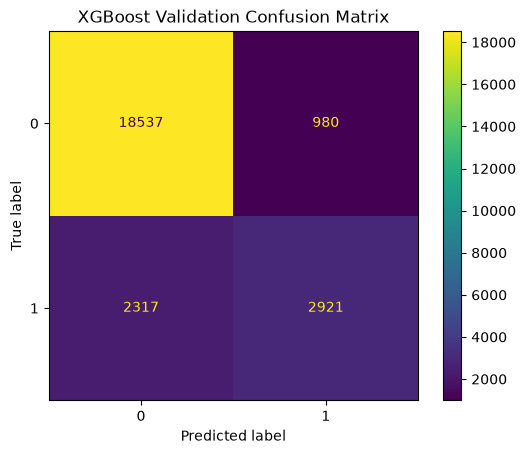

In [25]:
ConfusionMatrixDisplay.from_predictions(y_val, xgb_pred)
plt.title("XGBoost Validation Confusion Matrix")
plt.show()

### Hyperparameter Tuning


In [26]:
from sklearn.model_selection import RandomizedSearchCV

random_search_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="logloss"
    ))
])

param_distributions = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [3, 5, 7],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

random_search = RandomizedSearchCV(
    random_search_pipeline,
    param_distributions=param_distributions,
    n_iter=8,
    scoring="f1",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best parameters:")
print(random_search.best_params_)
print("\nBest cross-validation F1 score:", random_search.best_score_)


Best parameters:
{'model__subsample': 0.8, 'model__n_estimators': 300, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__colsample_bytree': 1.0}

Best cross-validation F1 score: 0.6360930753433126


## Tune XGBoost

In [27]:
tuned_xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=5,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        eval_metric="logloss"
    ))
])

tuned_xgb_model.fit(X_train, y_train)

tuned_xgb_pred = tuned_xgb_model.predict(X_val)
tuned_xgb_prob = tuned_xgb_model.predict_proba(X_val)[:, 1]

tuned_result = {
    "Model": "Tuned XGBoost",
    "Accuracy": accuracy_score(y_val, tuned_xgb_pred),
    "Precision": precision_score(y_val, tuned_xgb_pred, zero_division=0),
    "Recall": recall_score(y_val, tuned_xgb_pred, zero_division=0),
    "F1": f1_score(y_val, tuned_xgb_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_val, tuned_xgb_prob)
}

print(classification_report(y_val, tuned_xgb_pred))
print("ROC-AUC:", tuned_result["ROC-AUC"])

              precision    recall  f1-score   support

           0       0.89      0.95      0.92     19517
           1       0.75      0.55      0.64      5238

    accuracy                           0.87     24755
   macro avg       0.82      0.75      0.78     24755
weighted avg       0.86      0.87      0.86     24755

ROC-AUC: 0.8900361103231823


### Model Selection

The validation comparison is used to identify the strongest candidate according to the selected evaluation metrics. The held-out test set remains reserved for the final evaluation.

## 20. Final validation comparison

In [28]:
all_results = results.copy()

final_comparison = pd.concat(
    [all_results, pd.DataFrame([tuned_result])],
    ignore_index=True
).sort_values("F1", ascending=False).reset_index(drop=True)

display(final_comparison)

best_model_name = final_comparison.iloc[0]["Model"]
print("Best validation model:", best_model_name)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,XGBoost,0.866815,0.748782,0.557656,0.639238,0.889427
1,Tuned XGBoost,0.867340,0.753240,0.554792,0.638962,0.890036
2,Decision Tree,0.861725,0.731919,0.546774,0.625943,0.880671
3,Random Forest,0.858210,0.723025,0.534746,0.614794,0.873202
4,Logistic Regression,0.835185,0.701461,0.384880,0.497041,0.818628


Best validation model: XGBoost


## Conclusion

The best-performing model for this churn prediction task is XGBoost, because it achieved the highest validation F1 score and a strong ROC-AUC compared with the other models. This indicates that it balanced precision and recall better than Logistic Regression, Decision Tree, and Random Forest on the customer churn dataset. The model also handled the complex, non-linear relationships in the data more effectively, which is important in real-world classification tasks where customer behavior is influenced by multiple interacting factors.

Although the tuned XGBoost model was very close in performance, the standard XGBoost model produced the best validation result overall. Logistic Regression was simpler and faster, but it could not capture the more complex patterns in the dataset as well as the tree-based ensemble model. Therefore, XGBoost was selected as the final model because it delivered the strongest predictive performance while still maintaining a good balance between accuracy, recall, and F1 score.

## Final held-out test evaluation

The test set is used only after model selection. Here the tuned XGBoost is evaluated as the final candidate.

In [29]:
tuned_xgb_test_pred = tuned_xgb_model.predict(X_test)
tuned_xgb_test_prob = tuned_xgb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, tuned_xgb_test_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, tuned_xgb_test_prob))

              precision    recall  f1-score   support

           0       0.89      0.95      0.92     19518
           1       0.75      0.55      0.64      5238

    accuracy                           0.87     24756
   macro avg       0.82      0.75      0.78     24756
weighted avg       0.86      0.87      0.86     24756

Test ROC-AUC: 0.8875467152808028


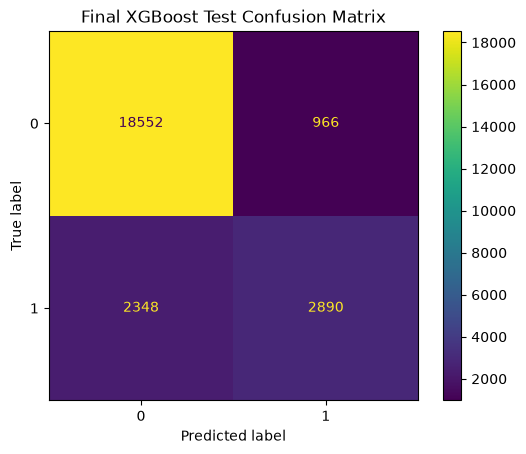

In [30]:
ConfusionMatrixDisplay.from_predictions(y_test, tuned_xgb_test_pred)
plt.title("Final XGBoost Test Confusion Matrix")
plt.show()